# numpy 
- 넘파이 배열을 만드는 방법 .array(파이썬 리스트 , 튜플 )
-  column_stack((배열1, 배열2))
- ones (갯수) : 갯수 만큼 1로 채운 넘파이 배열을 생성 
- zeros(갯수) : 갯수 만큼 0로 챠윤 넘파일 배열로 생성 
- concatenate: 넘파일 배열을 하난로 함쳐주는 기능 

In [46]:
import numpy as np

fish_length = np.array ([25.4, 26.3, 26.5, 29.0, 29.0, 29.7, 29.7, 30.0, 30.0, 30.7, 31.0, 31.0,
                31.5, 32.0, 32.0, 32.0, 33.0, 33.0, 33.5, 33.5, 34.0, 34.0, 34.5, 35.0,
                35.0, 35.0, 35.0, 36.0, 36.0, 37.0, 38.5, 38.5, 39.5, 41.0, 41.0, 9.8,
                10.5, 10.6, 11.0, 11.2, 11.3, 11.8, 11.8, 12.0, 12.2, 12.4, 13.0, 14.3, 15.0])
fish_weight = np.array( [242.0, 290.0, 340.0, 363.0, 430.0, 450.0, 500.0, 390.0, 450.0, 500.0, 475.0, 500.0,
                500.0, 340.0, 600.0, 600.0, 700.0, 700.0, 610.0, 650.0, 575.0, 685.0, 620.0, 680.0,
                700.0, 725.0, 720.0, 714.0, 850.0, 1000.0, 920.0, 955.0, 925.0, 975.0, 950.0, 6.7,
                7.5, 7.0, 9.7, 9.8, 8.7, 10.0, 9.9, 9.8, 12.2, 13.4, 12.2, 19.7, 19.9] )

In [47]:
fish_data = np.column_stack((fish_length, fish_weight))
fish_data

array([[  25.4,  242. ],
       [  26.3,  290. ],
       [  26.5,  340. ],
       [  29. ,  363. ],
       [  29. ,  430. ],
       [  29.7,  450. ],
       [  29.7,  500. ],
       [  30. ,  390. ],
       [  30. ,  450. ],
       [  30.7,  500. ],
       [  31. ,  475. ],
       [  31. ,  500. ],
       [  31.5,  500. ],
       [  32. ,  340. ],
       [  32. ,  600. ],
       [  32. ,  600. ],
       [  33. ,  700. ],
       [  33. ,  700. ],
       [  33.5,  610. ],
       [  33.5,  650. ],
       [  34. ,  575. ],
       [  34. ,  685. ],
       [  34.5,  620. ],
       [  35. ,  680. ],
       [  35. ,  700. ],
       [  35. ,  725. ],
       [  35. ,  720. ],
       [  36. ,  714. ],
       [  36. ,  850. ],
       [  37. , 1000. ],
       [  38.5,  920. ],
       [  38.5,  955. ],
       [  39.5,  925. ],
       [  41. ,  975. ],
       [  41. ,  950. ],
       [   9.8,    6.7],
       [  10.5,    7.5],
       [  10.6,    7. ],
       [  11. ,    9.7],
       [  11.2,    9.8],


In [48]:
fish_target = np.concatenate((np.ones(35), np.zeros(14)))

In [49]:
from sklearn.model_selection import train_test_split

In [50]:
train_input, test_input, train_target, test_target = train_test_split(fish_data, fish_target, random_state=42, test_size=0.2)

In [51]:
train_target[:10]

array([1., 1., 1., 1., 1., 1., 0., 0., 0., 1.])

In [52]:
test_target

array([1., 0., 0., 0., 1., 1., 1., 1., 1., 1.])

In [53]:
from sklearn.neighbors import KNeighborsClassifier
kn =  KNeighborsClassifier()

In [54]:
kn.fit(train_input, train_target)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [55]:
kn.score(test_input, test_target)

1.0

In [57]:
kn.predict([[25,150]])

array([0.])

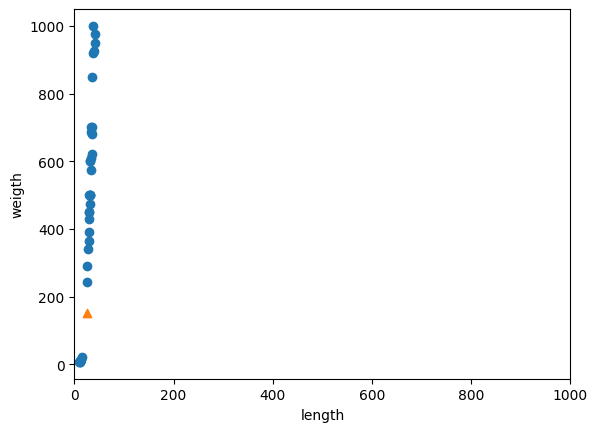

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(train_input[:,0], train_input[:, 1])
plt.scatter(25, 150, marker='^') # ^ -> 삼각형 , D-> 다이아 몬드 
plt.xlabel('length')
plt.ylabel('weigth')
plt.xlim(0,1000)
plt.show()

In [ ]:
"""
    -무게이든 길이든 모두 중요한 특성 !, 수치가 크다고 해서 특정 특성을 중요하게 볼 필요 없음 
    - 수치를 동일 한 기준 범위로 변환 - 정규화 
        예 ) 표준 점수 
        분산 : (측정값 - 평균)^2 + (측정값 - 평균) .. / 총 샘플 갯수 
        표준 편차: 분산에 제곱근 
        표준 점수 : (측정값 - 평균) + (측정값 - 평균) +(측정값 + 평균) ... / 표준편차 
"""

## kn.kneighbors([[....][...]]) : 반환값 (거리 근처이 있는 요소인텍스 )

In [68]:
distances, indexes= kn.kneighbors([[25,150]])

In [69]:
distances

array([[ 92.00086956, 130.48375378, 138.32150953, 140.00603558,
        140.62090883]])

In [70]:
indexes

array([[15, 32,  8, 22,  7]])

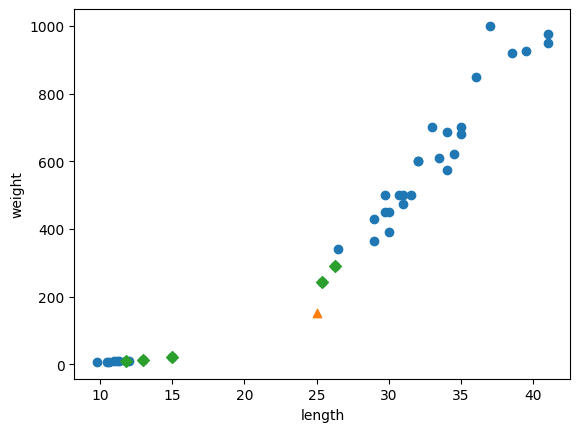

In [72]:

import matplotlib.pyplot as plt
plt.scatter(train_input[:, 0], train_input[:,1])
plt.scatter(25, 150, marker='^')  # ^ -> 삼각형, D -> 다이아몬드
plt.scatter(train_input[indexes, 0], train_input[indexes, 1], marker='D')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()